# Scattering time downturn validation - CHIME/FRB Selection Function 

### Author: Kyle McGregor (McGill University)

## Simulation procedure
This notebook mirrors the end-to-end simulation in `sanity_check.py`: draw an intrinsic population from the fiducial (F, DM, W, τ) model, scale τ to the selection-function reference frequency (1000 MHz), compute per-event selection probabilities with `SelectionFunction.calculate_selection_probability`, and compare intrinsic vs expected-detected vs Catalog 2 distributions.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import lognorm

import chimefrb_selection as cfsf

# ===========================
# USER PARAMS
# ===========================
BETA = -0.231 # tail slope in "pdf units per dex" for the semi-log tail
N_POP = 100_000
RNG_SEED = 12346

CAT2_JSON = "/data/user-data/ssiegel/catalog2/table/20251121/chimefrbcat2.json"

## Scattering model: lognormal rise + semi-log tail (LognormalSemiLogTail)
Copied from the reference script to ensure identical sampling and normalization.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm


class LognormalSemiLogTail:
    """
    Lognormal up to the log-binned peak + *semi-log linear* tail after the peak.

    What "semi-log linear tail" means
    ---------------------------------
    Let f(x) be the PDF in linear-x. Counts per d(log x) are proportional to:

        h(x) = x f(x)

    If you plot a log-binned histogram (log-spaced bins) with:
        x-axis = log scale
        y-axis = linear counts

    then you are effectively visualizing h(x) as a function of log x.

    To make the tail look like a *straight line* on a log-x / linear-y plot, we set
    the tail *log-binned height* to be linear in ln x:

        h_tail(x) = h_p * [1 + beta * ln(x/pivot)]    for x >= pivot

    where:
        h_p = pivot * f_lognorm(pivot)

    This yields the tail PDF:
        f_tail(x) = h_tail(x) / x
                  = h_p * [1 + beta * ln(x/pivot)] / x

    Parameter
    ---------
    beta:
      Slope in ln(x) space of the *log-binned height* beyond the pivot.

      beta = 0      -> flat plateau in log-binned counts (log-uniform tail; f ∝ 1/x)
      beta < 0      -> downward-tilting plateau, *linear* on log-x/linear-y
      beta > 0      -> upward-tilting plateau, *linear* on log-x/linear-y

    Constraints
    -----------
    For a valid nonnegative tail height over [pivot, tau_max], we need:
        1 + beta * L >= 0,
    where L = ln(tau_max/pivot).

    Units
    -----
    tau is in SECONDS throughout (rvs returns seconds).
    The fiducial model is at 600 MHz.

    Join / matching
    ---------------
    pivot is chosen at the peak of x f_lognorm(x), which for a lognormal is pivot = scale.
    We match log-binned height at pivot:
        h_tail(pivot) = h_p = pivot * f_lognorm(pivot)
    automatically, because ln(pivot/pivot)=0.

    Sampling
    --------
    Mixture sampling:
      - left component: lognormal truncated to [tau_min, pivot]
      - right component: tail on [pivot, tau_max] with f_tail(x) ∝ (1 + beta ln(x/pivot))/x

    For the tail, define t = ln(x/pivot) in [0, L]. Because dx/x = dt,
    the induced density in t is linear:
        p(t) ∝ 1 + beta t,  t ∈ [0, L]
    which we can sample by inverting a quadratic CDF.
    """

    def __init__(
        self,
        beta: float = 0.0,
        *,
        sigma: float = 1.94,
        scale: float = 0.0131,   # seconds (SciPy lognorm scale parameter), at 600 MHz
        tau_min: float = 1e-5,   # seconds
        tau_max: float = 1.0,    # seconds
        eps_height: float = 1e-12,  # numerical slack for nonnegativity
    ):
        self.beta = float(beta)
        self.sigma = float(sigma)
        self.scale = float(scale)
        self.tau_min = float(tau_min)
        self.tau_max = float(tau_max)
        self.eps_height = float(eps_height)

        if not (np.isfinite(self.beta) and np.isfinite(self.sigma) and np.isfinite(self.scale)):
            raise ValueError("beta, sigma, scale must be finite.")
        if self.sigma <= 0:
            raise ValueError("sigma must be > 0.")
        if not (self.scale > 0 and self.tau_min > 0 and self.tau_max > self.tau_min):
            raise ValueError("Need scale>0 and 0<tau_min<tau_max.")

        self._ln = lognorm(s=self.sigma, scale=self.scale)

        self.pivot = float(np.clip(self.scale, self.tau_min, self.tau_max))
        self._L = float(np.log(self.tau_max / self.pivot)) if self.tau_max > self.pivot else 0.0

        # Enforce: tail height factor >= 0 on [pivot, tau_max]
        if self._L > 0:
            self.beta_zero = -1.0 / self._L   # makes height hit 0 at tau_max
            if self.beta < self.beta_zero:
                self.beta = self.beta_zero    # clamp so it never goes negative early

        self._w_left = self._compute_w_left()

    # --------------------
    # Core helpers
    # --------------------
    def _h_p(self) -> float:
        # log-binned height at pivot from the lognormal
        return self.pivot * float(self._ln.pdf(self.pivot))

    def _tail_height_factor(self, tau: np.ndarray) -> np.ndarray:
        # 1 + beta*ln(tau/pivot), clipped to 0 for numerical safety
        t = np.log(np.asarray(tau, dtype=float) / self.pivot)
        return np.maximum(0.0, 1.0 + self.beta * t)

    def _compute_w_left(self) -> float:
        # left mass under normalized lognormal on [tau_min, pivot]
        c_lo = self._ln.cdf(self.tau_min)
        c_p = self._ln.cdf(self.pivot)
        left_mass = float(np.clip(c_p - c_lo, 0.0, 1.0))

        # right mass under tail on [pivot, tau_max]
        if self.tau_max <= self.pivot * (1.0 + 1e-15):
            right_mass = 0.0
        else:
            # mass_right = ∫ f_tail(x) dx
            # with t=ln(x/pivot), dx/x = dt:
            # f_tail dx = h_p*(1+beta t)/x * dx = h_p*(1+beta t) dt
            # so mass_right = h_p * ∫_0^L (1+beta t) dt = h_p*(L + 0.5*beta*L^2)
            h_p = self._h_p()
            L = self._L
            right_mass = h_p * (L + 0.5 * self.beta * L * L)
            right_mass = float(max(right_mass, 0.0))

        total = left_mass + right_mass
        if not (np.isfinite(total) and total > 0):
            raise RuntimeError("Total mass is non-positive; check parameters/bounds.")
        return left_mass / total

    # --------------------
    # Public API
    # --------------------
    def pdf_unnorm(self, tau: np.ndarray) -> np.ndarray:
        """
        Unnormalized piecewise density (continuous in log-binned height at pivot).
        """
        tau = np.asarray(tau, dtype=float)
        out = np.zeros_like(tau)

        ok = np.isfinite(tau) & (tau >= self.tau_min) & (tau <= self.tau_max)
        if not np.any(ok):
            return out

        t = tau[ok]
        left = t <= self.pivot
        right = ~left

        p = np.zeros_like(t)

        if np.any(left):
            p[left] = self._ln.pdf(t[left])

        if np.any(right):
            h_p = self._h_p()
            fac = self._tail_height_factor(t[right])
            p[right] = h_p * fac / t[right]   # f_tail(x) = h(x)/x

        out[ok] = np.maximum(p, 0.0)
        return out

    def pdf(self, tau: np.ndarray, ngrid_Z: int = 8192) -> np.ndarray:
        """
        Normalized pdf via numeric normalization (trapz) on log grid.
        """
        tau = np.asarray(tau, dtype=float)
        grid = np.geomspace(self.tau_min, self.tau_max, int(ngrid_Z))
        z = np.trapz(self.pdf_unnorm(grid), grid)
        if not (np.isfinite(z) and z > 0):
            raise RuntimeError("Normalization failed.")
        return self.pdf_unnorm(tau) / z

    def rvs(self, size: int = 1, random_state=None) -> np.ndarray:
        """
        Draw samples (seconds, at 600 MHz) using exact inverse transforms for each component.
        """
        n = int(size)
        if n < 0:
            raise ValueError("size must be >= 0.")
        rng = np.random.default_rng(random_state)

        u = rng.uniform(0.0, 1.0, size=n)
        left = u < self._w_left
        n_left = int(np.sum(left))
        n_right = n - n_left

        out = np.empty(n, dtype=float)

        # Left: lognormal truncated to [tau_min, pivot]
        if n_left > 0:
            c_lo = self._ln.cdf(self.tau_min)
            c_p = self._ln.cdf(self.pivot)
            if c_p <= c_lo:
                out[left] = self.tau_min
            else:
                u_left = rng.uniform(c_lo, c_p, size=n_left)
                out[left] = np.clip(self._ln.ppf(u_left), self.tau_min, self.pivot)

        # Right: semi-log-linear tail on [pivot, tau_max]
        if n_right > 0:
            if self.tau_max <= self.pivot * (1.0 + 1e-15):
                out[~left] = self.pivot
            else:
                L = self._L
                ur = rng.uniform(0.0, 1.0, size=n_right)

                # Sample t in [0, L] with pdf p(t) ∝ 1 + beta t
                b = self.beta
                if abs(b) < 1e-14:
                    # uniform in t
                    t = ur * L
                else:
                    # CDF: F(t) = (t + 0.5 b t^2) / (L + 0.5 b L^2)
                    Z = L + 0.5 * b * L * L
                    # Solve (b/2)t^2 + t - uZ = 0
                    disc = 1.0 + 2.0 * b * ur * Z
                    disc = np.maximum(disc, 0.0)
                    t = (-1.0 + np.sqrt(disc)) / b
                    # numerical clip
                    t = np.clip(t, 0.0, L)

                out[~left] = self.pivot * np.exp(t)

        return np.clip(out, self.tau_min, self.tau_max)

    def plot_logbinned_counts(self, ax=None, n=200_000, bins=60, random_state=0, label=None):
        """
        Convenience: draw samples and plot log-binned counts (seconds on x-axis).
        """
        if ax is None:
            _, ax = plt.subplots(figsize=(6, 4))
        x = self.rvs(size=n, random_state=random_state)
        b = np.geomspace(self.tau_min, self.tau_max, int(bins))
        ax.hist(x, bins=b, histtype="step", linewidth=2, label=label or f"beta={self.beta:g}")
        ax.set_xscale("log")
        ax.set_xlabel(r"$\tau$ (s)")
        ax.set_ylabel("Counts (log-spaced bins)")
        return ax

### Quick sanity plot of the scattering draw in log-spaced bins

NameError: name 'L' is not defined

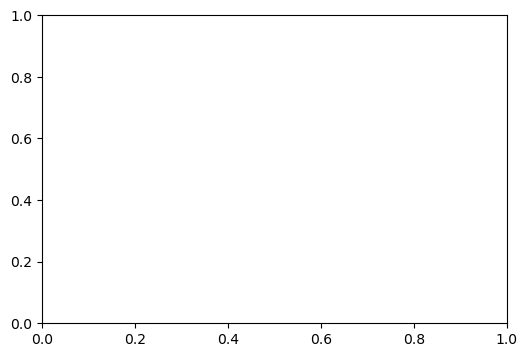

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
for beta in [-0.81, 0.0, 0.8]:
    LognormalSemiLogTail(beta=beta).plot_logbinned_counts(
        ax=ax, n=200_000, bins=60, random_state=0, label=fr"$\beta={beta}$"
    )
ax.legend(frameon=False)
ax.set_title("Scattering draws at 600 MHz (seconds), log-spaced bins")
plt.show()

## Selection function
Instantiate the 4D SelectionFunction exactly as in the reference script.

In [5]:
def build_selection_function():
    return cfsf.SelectionFunction(
        predictor_names=["fluence", "scattering_time", "width", "dm"],
        degree=3,
        snr_cut=12.0,
        exclude_sidelobes=True,
        sidelobe_cut=5.0,
        reweighted=False,
    )

sf = build_selection_function()

## Fiducial intrinsic sampling
Same truncated power-law fluence, truncated lognormal DM/width, and LognormalSemiLogTail scattering. Scattering is drawn at 600 MHz (s) and scaled to 1000 MHz (s) for the SF.

In [6]:
def draw_fluence_powerlaw_truncated(N, alpha_tail, xmin, xmax, rng):
    if not (xmin > 0 and xmax > xmin):
        raise ValueError("Need xmin > 0 and xmax > xmin.")
    if not (alpha_tail < 0):
        raise ValueError("alpha_tail must be < 0 for this convention.")
    s_max = (xmax / xmin) ** alpha_tail
    u = rng.uniform(s_max, 1.0, size=N)
    return xmin * (u ** (1.0 / alpha_tail))


def sample_truncated_lognorm_icdf(N, sigma_ln, scale, lo, hi, rng):
    if not (sigma_ln > 0 and scale > 0 and lo > 0 and hi > lo):
        raise ValueError("Need sigma_ln>0, scale>0, lo>0, hi>lo.")
    dist = lognorm(s=sigma_ln, scale=scale)
    c_lo = dist.cdf(lo)
    c_hi = dist.cdf(hi)
    if not (np.isfinite(c_lo) and np.isfinite(c_hi) and c_hi > c_lo):
        raise RuntimeError("Bad truncation window for this lognormal (CDF bounds invalid).")
    u = rng.uniform(c_lo, c_hi, size=N)
    x = dist.ppf(u)
    return np.clip(x, lo, hi)


def sample_fiducial_from_params(N: int, rng: np.random.Generator, beta: float):
    # ---- fiducial parameters ----
    alpha_tail = -1.203108427072943

    dm_shape = 0.6076516890745998
    dm_scale = 534.4727066208081  # pc cm^-3

    width_shape = 1.1012853240184415
    width_scale = 0.0007389903164298552  # seconds

    # ---- fluence bounds ----
    FMIN, FMAX = 0.1, 10000.0  # Jy ms

    fluence_jy_ms = draw_fluence_powerlaw_truncated(
        N, alpha_tail=alpha_tail, xmin=FMIN, xmax=FMAX, rng=rng
    )

    dm_pc_cm3 = sample_truncated_lognorm_icdf(
        N, sigma_ln=dm_shape, scale=dm_scale, lo=100.0, hi=5000.0, rng=rng
    )

    width_s = sample_truncated_lognorm_icdf(
        N, sigma_ln=width_shape, scale=width_scale, lo=1e-4, hi=0.2, rng=rng
    )

    # ---- Scattering: sampled at 600 MHz in seconds, scaled to 1000 MHz reference (seconds) ----
    scat_model = LognormalSemiLogTail(beta=beta)
    scattering_s = scat_model.rvs(size=N, random_state=rng)
    scattering_s = scattering_s * (600.0 / 1000.0) ** 4  # 600 MHz -> 1000 MHz

    return fluence_jy_ms, scattering_s, width_s, dm_pc_cm3

## Selection probability computation
Loop over events with `tqdm` and call `calculate_selection_probability` using the exact input keys and units.

In [7]:
def compute_pdet(sf, fluence_jy_ms, scattering_s, width_s, dm_pc_cm3):
    """
    scattering_s is already at 1000 MHz in seconds (scaled at sampling time).
    SF expects 1000 MHz in ms, so just * 1e3.
    """
    N = fluence_jy_ms.size
    pdet = np.full(N, np.nan, dtype=float)

    for i in tqdm(range(N), desc="Computing p_det"):
        try:
            pdet[i] = sf.calculate_selection_probability(
                {
                    "fluence_jy_ms": float(fluence_jy_ms[i]),
                    "scattering_time": float(scattering_s[i] * 1e3),  # 1000 MHz s -> ms
                    "width": float(width_s[i] * 1e3),                 # s -> ms
                    "dm": float(dm_pc_cm3[i]),
                }
            )
        except ValueError:
            continue

    good = np.isfinite(pdet)
    pdet[good] = np.clip(pdet[good], 0.0, 1.0)
    valid = good
    return pdet, valid

## Catalog 2 loading and minimal cuts
Key-robust extraction and minimal (SNR, DM) cuts copied from the reference script.

In [8]:
def load_cat2_catalog_json(path: str):
    with open(path, "r") as f:
        cat = json.load(f)
    return cat


def pick_first_existing_key(d: dict, keys: list[str]):
    for k in keys:
        if k in d:
            return k
    return None


def to_float_or_nan(x):
    try:
        if isinstance(x, str):
            x = x.strip()
            if x.startswith("<"):
                x = x[1:]
        if isinstance(x, list) and len(x) > 0:
            return to_float_or_nan(x[0])
        return float(x)
    except Exception:
        return np.nan


def minimal_catalog_cuts(cat: list[dict], snr_cut=12.0, dm_lo=100.0, dm_hi=5000.0):
    out = []
    for frb in cat:
        snr = to_float_or_nan(frb.get("bonsai_snr", np.nan))
        dm = to_float_or_nan(frb.get("dm_fitb", np.nan))
        if not (np.isfinite(snr) and snr >= snr_cut):
            continue
        if not (np.isfinite(dm) and (dm_lo <= dm <= dm_hi)):
            continue
        out.append(frb)
    return out


def extract_catalog_arrays(cat_cut: list[dict]):
    dm = np.array([to_float_or_nan(frb.get("dm_fitb", np.nan)) for frb in cat_cut], dtype=float)

    width_key = None
    if len(cat_cut) > 0:
        width_key = pick_first_existing_key(cat_cut[0], ["width_fitb", "bc_width", "width"])
    width_s = (
        np.array([to_float_or_nan(frb.get(width_key, np.nan)) for frb in cat_cut], dtype=float)
        if width_key
        else np.full(len(cat_cut), np.nan)
    )
    if np.nanmedian(width_s) > 0.5:  # likely ms
        width_s = width_s * 1e-3

    scat_key = None
    if len(cat_cut) > 0:
        scat_key = pick_first_existing_key(cat_cut[0], ["scat_time", "scattering_time", "tau"])
    scattering_ms = (
        np.array([to_float_or_nan(frb.get(scat_key, np.nan)) for frb in cat_cut], dtype=float)
        if scat_key
        else np.full(len(cat_cut), np.nan)
    )
    # Catalog scattering is at 400 MHz in ms in the raw JSON.
    # The median heuristic converts to seconds if median > 0.5 (i.e. values are in ms).
    if np.nanmedian(scattering_ms) > 0.5:
        scattering_ms = scattering_ms * 1e-3  # ms -> s

    fluence_key = None
    if len(cat_cut) > 0:
        fluence_key = pick_first_existing_key(
            cat_cut[0],
            ["fluence_jy_ms", "fluence", "fluence_fitb", "band_fluence", "mean_fluence", "fluence_mean"],
        )

    if fluence_key is not None:
        fluence = np.array([to_float_or_nan(frb.get(fluence_key, np.nan)) for frb in cat_cut], dtype=float)
        fluence_label = "Catalog fluence"
    else:
        fluence = np.array([to_float_or_nan(frb.get("bonsai_snr", np.nan)) for frb in cat_cut], dtype=float)
        fluence_label = "Catalog S/N (bonsai_snr) (no fluence key found)"

    return fluence, scattering_ms, width_s, dm, fluence_label

## Plot: intrinsic vs expected-detected vs catalog counts
Bottom row: expected-detected histogram weights are `p_det` scaled so the total equals the finite catalog count in that panel. The scattering panel is fixed to 10^-2 to 10^2 ms.

In [10]:
def make_3x4_hist_plot(
    fluence_jy_ms,
    scattering_s,       # model scattering at 1000 MHz in seconds
    width_s,
    dm_pc_cm3,
    pdet,
    valid,
    cat_fluence,
    cat_scattering_ms,  # catalog scattering at 1000 MHz in ms
    cat_width_s,
    cat_dm_pc_cm3,
    cat_fluence_label,
):
    panels = [
        ("Fluence (Jy ms)",             np.asarray(fluence_jy_ms),        np.asarray(cat_fluence),        cat_fluence_label),
        ("Scattering @ 1000 MHz (ms)",  np.asarray(scattering_s) * 1e3,   np.asarray(cat_scattering_ms),  "Catalog scattering"),
        ("Width (ms)",                  np.asarray(width_s) * 1e3,        np.asarray(cat_width_s) * 1e3,  "Catalog width"),
        ("DM (pc cm$^{-3}$)",           np.asarray(dm_pc_cm3),            np.asarray(cat_dm_pc_cm3),      "Catalog DM"),
    ]

    bins = {}
    for title, arr_intr, _, _ in panels:
        arr_intr = arr_intr[np.isfinite(arr_intr) & (arr_intr > 0)]
        if "DM" in title:
            bins[title] = np.geomspace(100, 5000, 40)
        elif "Fluence" in title:
            bins[title] = np.geomspace(0.1, 10000, 40)
        elif "Scattering" in title:
            bins[title] = np.geomspace(1e-5 * 1e3, 1.0 * 1e3, 40)
        elif "Width" in title:
            bins[title] = np.geomspace(1e-2, 1e2, 50)
        else:
            lo, hi = np.nanpercentile(arr_intr, [0.5, 99.5])
            lo = max(lo, 1e-12)
            hi = max(hi, lo * 1.01)
            bins[title] = np.logspace(np.log10(lo), np.log10(hi), 40)

    fig, axes = plt.subplots(2, 4, figsize=(16, 9), constrained_layout=True)

    # Row 1: intrinsic counts
    for j, (title, arr_intr, _, _) in enumerate(panels):
        ax = axes[0, j]
        ax.hist(arr_intr[np.isfinite(arr_intr) & (arr_intr > 0)], bins=bins[title], histtype="step", linewidth=2)
        ax.set_title(title)
        if j == 0:
            ax.set_ylabel("Intrinsic counts")
        ax.set_xscale("log")

    # Row 2: expected detected counts (scaled per panel to match catalog finite count)
    for j, (title, arr_intr, arr_cat, _) in enumerate(panels):
        ax = axes[1, j]

        m_intr = np.isfinite(arr_intr) & (arr_intr > 0) & valid & np.isfinite(pdet)
        expected_raw = np.nansum(pdet[m_intr])
        if expected_raw <= 0:
            continue

        m_cat = np.isfinite(arr_cat) & (arr_cat > 0)
        catalog_size_panel = int(np.sum(m_cat))
        weights = pdet[m_intr] * (catalog_size_panel / expected_raw)

        ax.hist(arr_intr[m_intr], bins=bins[title], weights=weights, histtype="step", linewidth=2)
        if j == 0:
            ax.set_ylabel("Expected detected counts")
        ax.set_xscale("log")

    # Overlay catalog counts on the same bottom row axes
    for j, (title, _, arr_cat, cat_label) in enumerate(panels):
        ax = axes[1, j]
        m = np.isfinite(arr_cat) & (arr_cat > 0)
        ax.hist(arr_cat[m], bins=bins[title], histtype="step", linewidth=2)
        if j == 0 and ("bonsai_snr" in cat_label):
            ax.set_title("Fluence panel = bonsai_snr proxy")
        ax.set_xscale("log")

    fig.suptitle(
        f"Intrinsic draws (top) and expected detected + Catalog 2 (bottom) — beta={BETA:g}",
        y=1.02,
    )
    return fig

## Run the full simulation

In [15]:
rng = np.random.default_rng(RNG_SEED)

# Intrinsic draws (model)
fluence_jy_ms, scattering_s_1ghz, width_s, dm_pc_cm3 = sample_fiducial_from_params(
    N_POP, rng, beta=BETA
)

# Selection probabilities
pdet, valid = compute_pdet(sf, fluence_jy_ms, scattering_s_1ghz, width_s, dm_pc_cm3)

# Catalog (with minimal cuts)
cat = load_cat2_catalog_json(CAT2_JSON)
cat_cut = minimal_catalog_cuts(cat, snr_cut=12.0, dm_lo=100.0, dm_hi=5000.0)
cat_fluence, cat_scattering_s, cat_width_s, cat_dm, cat_fluence_label = extract_catalog_arrays(cat_cut)

# Convert catalog scattering to 1000 MHz reference in ms (matching the plotting panel)
# Raw catalog scattering is effectively at 400 MHz; we scale tau ∝ nu^-4.
cat_scattering_ms_1ghz = cat_scattering_s * (400.0 / 1000.0) ** 4 * 1e3  # (400 MHz seconds) -> (1000 MHz ms)

Computing p_det:   0%|          | 0/100000 [00:00<?, ?it/s]

Computing p_det: 100%|██████████| 100000/100000 [02:32<00:00, 654.42it/s]


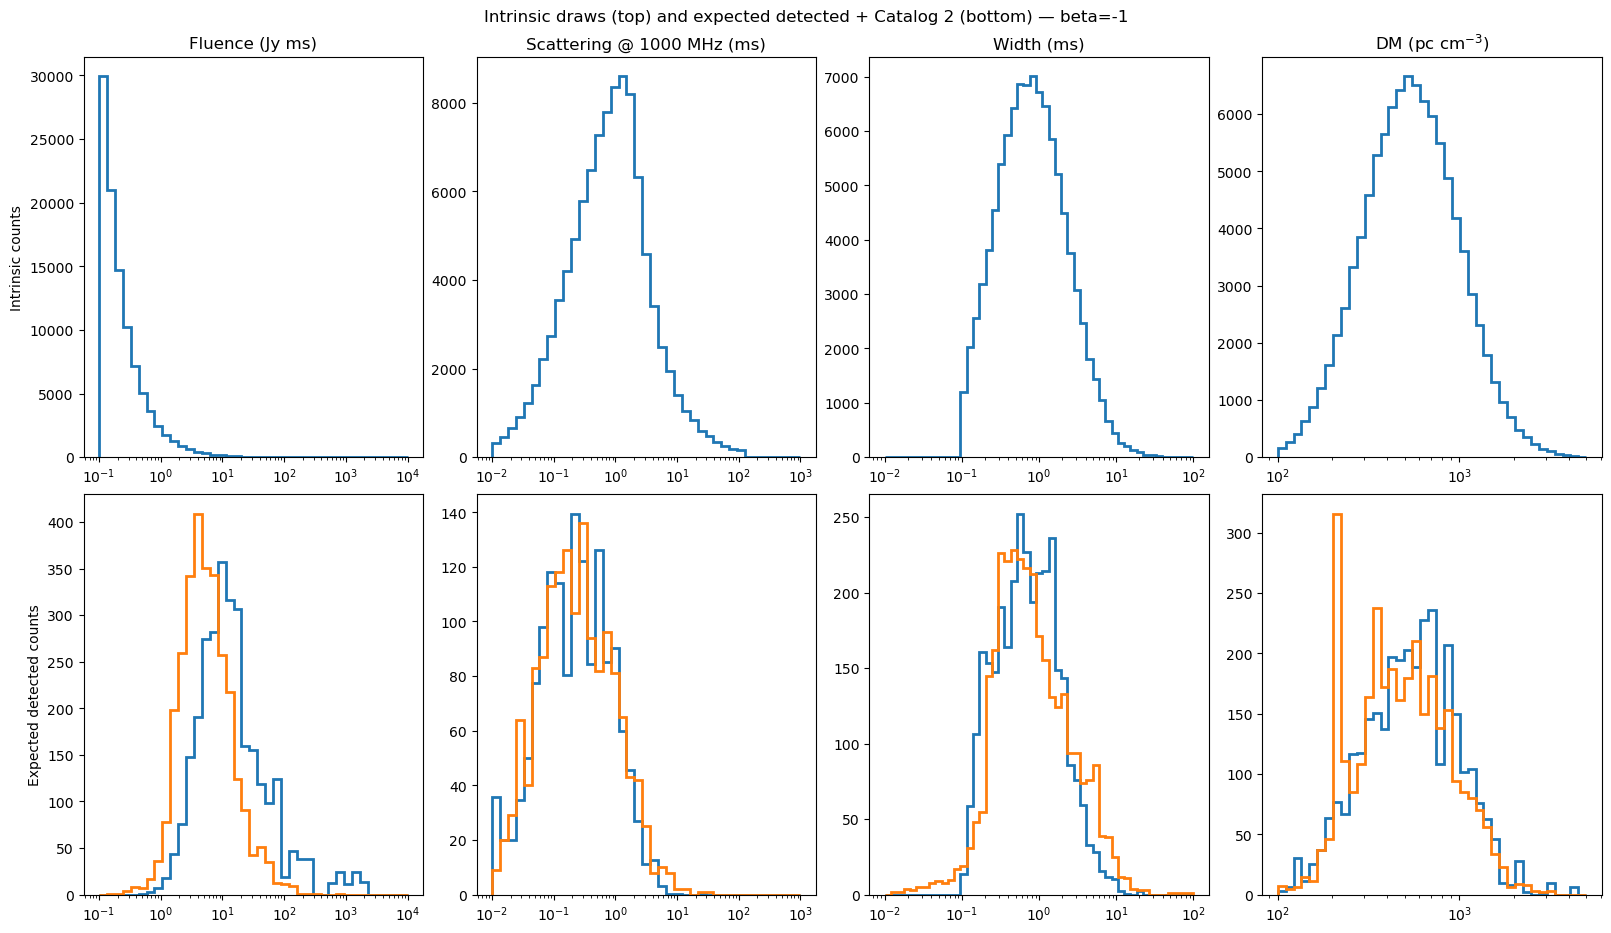

In [16]:
fig = make_3x4_hist_plot(
    fluence_jy_ms, scattering_s_1ghz, width_s, dm_pc_cm3,
    pdet=pdet, valid=valid,
    cat_fluence=cat_fluence,
    cat_scattering_ms=cat_scattering_ms_1ghz,
    cat_width_s=cat_width_s,
    cat_dm_pc_cm3=cat_dm,
    cat_fluence_label=cat_fluence_label,
)
plt.show()